In [22]:
import os
import sys

# 実行環境の確認
if "google.colab" in sys.modules:
    print("✓ Running in Google Colab")
else:
    print("✗ Running locally (not Colab)")

print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
print(f"Working Directory: {os.getcwd()}")

✗ Running locally (not Colab)
Python version: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Executable: /home/user/deep-learning-from-scratch-2/.venv/bin/python
Working Directory: /home/user/deep-learning-from-scratch-2/notebooks


In [7]:
# Colab で実行している場合、リポジトリをクローンする
#!git clone -b master https://github.com/oreilly-japan/deep-learning-from-scratch-2.git
#%cd deep-learning-from-scratch-2
#sys.path.append('.')

In [ ]:
sys.path.append('..')

import pickle

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from ch06.better_rnnlm import BetterRnnlm
from ch06.rnnlm import Rnnlm
from common.base_model import BaseModel
from common.functions import softmax
from common.optimizer import Adam
from common.time_layers import *
from common.trainer import Trainer
from common.util import eval_seq2seq
from dataset import ptb, sequence


# 第 7 章 RNN による文章生成

前章では、LSTM を用いた言語モデルを学習し、PTB データセットに対するパープレキシティを改善しました。この章では、その学習済み言語モデルを使って「次に来る単語」を確率的に選び、文章を生成します。  
さらに、RNN を「入力系列から出力系列へ変換するモデル」として捉え直し、seq2seq による簡単な足し算問題へ発展させます。

## 7.1 言語モデルを使った文章生成
言語モデルは、これまでの単語列 $w_1, \dots, w_{t-1}$ から次の単語 $w_t$ の確率分布を出力します。文章生成では、この確率分布から単語 ID をサンプリングし、その単語を次の入力として再びモデルに与えます。この処理を繰り返すことで、任意の長さの単語列を生成できます。


### 7.1.1 RNN による文章生成の手順
`RnnlmGen` は 6 章の `Rnnlm` に `generate` メソッドを追加したクラスです。生成処理の流れは以下の通りです。

1. 開始単語 `start_id` を入力します。  
2. モデルの出力スコアを `softmax` で確率分布に変換します。  
3. `np.random.choice` により、確率に従って次の単語 ID を選びます。  
4. 選ばれた単語 ID を次の時刻の入力として使います。  

最大確率の単語を常に選ぶのではなくサンプリングするため、同じ開始単語でも実行ごとに異なる文章が生成されます。


In [ ]:
# coding: utf-8
# rnnlm_gen.py

class RnnlmGen(Rnnlm):
    def generate(self, start_id, skip_ids=None, sample_size=100):
        word_ids = [start_id]

        x = start_id
        while len(word_ids) < sample_size:
            x = np.array(x).reshape(1, 1)
            score = self.predict(x)
            p = softmax(score.flatten())

            sampled = int(np.random.choice(len(p), p=p))
            if (skip_ids is None) or (sampled not in skip_ids):
                x = sampled
                word_ids.append(sampled)

        return word_ids

    def get_state(self):
        return self.lstm_layer.h, self.lstm_layer.c

    def set_state(self, state):
        self.lstm_layer.set_state(*state)


class BetterRnnlmGen(BetterRnnlm):
    def generate(self, start_id, skip_ids=None, sample_size=100):
        word_ids = [start_id]

        x = start_id
        while len(word_ids) < sample_size:
            x = np.array(x).reshape(1, 1)
            score = self.predict(x).flatten()
            p = softmax(score).flatten()

            sampled = int(np.random.choice(len(p), p=p))
            if (skip_ids is None) or (sampled not in skip_ids):
                x = sampled
                word_ids.append(sampled)

        return word_ids

    def get_state(self):
        states = []
        for layer in self.lstm_layers:
            states.append((layer.h, layer.c))
        return states

    def set_state(self, states):
        for layer, state in zip(self.lstm_layers, states):
            layer.set_state(*state)

### 7.1.2 学習済みモデルから文章を生成する
ここでは 6 章で保存した `Rnnlm.pkl` を読み込み、`you` を開始単語として文章を生成します。`N`、`<unk>`、`$` は文として読みづらくなりやすいため、`skip_words` として除外しています。

生成結果の品質は、言語モデルの学習状態に依存します。より良いモデルを使えば、より自然な単語列が得られます。


In [37]:
# coding: utf-8
# generate_text.py


corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
corpus_size = len(corpus)

model = RnnlmGen()
model.load_params('../ch06/Rnnlm.pkl')

# start文字とskip文字の設定
start_word = 'you'
start_id = word_to_id[start_word]
skip_words = ['N', '<unk>', '$']
skip_ids = [word_to_id[w] for w in skip_words]
# 文章生成
word_ids = model.generate(start_id, skip_ids)
txt = ' '.join([id_to_word[i] for i in word_ids])
txt = txt.replace(' <eos>', '.\n')
print(txt)


you become skiing.
 and sri.
 for takeover-stock key consumer tv companies are increasingly nothing in the market.
 southam said it will absence about # billion and record value to profit.
 a one-time loss moved to from the battery conn. securities group well.
 colon f. downey corp. the devices rose at around end because china 's growth in non-u.s..
 american express 's chairman of ad staff fired out of its travel leaders in all.
 he said the applicants could index have only oppose an goals for powerful bank leaders by the earthquake apply to


In [39]:
# coding: utf-8
# generate_better_text.py


corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
corpus_size = len(corpus)

model = BetterRnnlmGen()
model.load_params('../ch06/BetterRnnlm.pkl')

# start文字とskip文字の設定
start_word = 'you'
start_id = word_to_id[start_word]
skip_words = ['N', '<unk>', '$']
skip_ids = [word_to_id[w] for w in skip_words]
# 文章生成
word_ids = model.generate(start_id, skip_ids)
txt = ' '.join([id_to_word[i] for i in word_ids])
txt = txt.replace(' <eos>', '.\n')
print(txt)


you do n't have a careful impact on the entire upheaval as those known as small companies.
 they also are designed to end the takeover as required.
 i think it is correct said james j. schwartz his routine showroom to veteran.
 an upscale raider tells the financial problem warns ronald state of former a unit of the european division of economic accounting systems inc.
 some of the letter today is to make more detailed goals.
 when fireman 's fund chairman william applied said he would call other zones.
 mr. founded is chairman of the


## 7.2 seq2seq

seq2seq (sequence to sequence) は、ある系列を別の系列へ変換するためのモデルです。機械翻訳のように「日本語の単語列」から「英語の単語列」を出力する問題だけでなく、文字列として表された計算式から答えの文字列を出力する問題にも使えます。

本章では、入力を足し算の式、出力を計算結果とする小さなタスクを通して seq2seq の仕組みを確認します。


### 7.2.1 足し算データセット
`addition.txt` には、固定長の足し算問題とその答えが文字単位で格納されています。入力 `71+118` は 7 文字、出力 `_189` は 5 文字で表されます。先頭の `_` はデコーダに生成開始を知らせる区切り文字として使います。

seq2seq は単語だけでなく文字 ID の系列も扱えるため、このデータセットでは数字や記号を vocabulary として扱います。


In [ ]:
# coding: utf-8
# show_addition_dataset.py


(x_train, t_train), (x_test, t_test) = \
    sequence.load_data('addition.txt', seed=1984)
char_to_id, id_to_char = sequence.get_vocab()

print(x_train.shape, t_train.shape)
print(x_test.shape, t_test.shape)
# (45000, 7) (45000, 5)
# (5000, 7) (5000, 5)

print(x_train[0])
print(t_train[0])
# [ 3  0  2  0  0 11  5]
# [ 6  0 11  7  5]

print(''.join([id_to_char[c] for c in x_train[0]]))
print(''.join([id_to_char[c] for c in t_train[0]]))
# 71+118
# _189


(45000, 7) (45000, 5)
(5000, 7) (5000, 5)
[ 3  0  2  0  0 11  5]
[ 6  0 11  7  5]
71+118 
_189 


### 7.2.2 Encoder と Decoder
seq2seq は大きく Encoder と Decoder の 2 つから構成されます。

Encoder は入力系列全体を LSTM で読み込み、最後の隠れ状態 $h$ に入力情報を圧縮します。Decoder はその $h$ を初期状態として受け取り、出力系列を 1 文字ずつ生成します。つまり、Encoder の最後の隠れ状態が、入力系列から出力系列へ情報を橋渡しする役割を持ちます。

学習時は正解系列を 1 文字ずらして Decoder に入力し、次の文字を予測するように損失を計算します。推論時は、直前に生成した文字を次の入力として使います。


In [ ]:
# coding: utf-8
# seq2seq.py


class Encoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=False)

        self.params = self.embed.params + self.lstm.params
        self.grads = self.embed.grads + self.lstm.grads
        self.hs = None

    def forward(self, xs):
        xs = self.embed.forward(xs)
        hs = self.lstm.forward(xs)
        self.hs = hs
        return hs[:, -1, :]

    def backward(self, dh):
        dhs = np.zeros_like(self.hs)
        dhs[:, -1, :] = dh

        dout = self.lstm.backward(dhs)
        dout = self.embed.backward(dout)
        return dout


class Decoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.affine = TimeAffine(affine_W, affine_b)

        self.params, self.grads = [], []
        for layer in (self.embed, self.lstm, self.affine):
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, h):
        self.lstm.set_state(h)

        out = self.embed.forward(xs)
        out = self.lstm.forward(out)
        score = self.affine.forward(out)
        return score

    def backward(self, dscore):
        dout = self.affine.backward(dscore)
        dout = self.lstm.backward(dout)
        dout = self.embed.backward(dout)
        dh = self.lstm.dh
        return dh

    def generate(self, h, start_id, sample_size):
        sampled = []
        sample_id = start_id
        self.lstm.set_state(h)

        for _ in range(sample_size):
            x = np.array(sample_id).reshape((1, 1))
            out = self.embed.forward(x)
            out = self.lstm.forward(out)
            score = self.affine.forward(out)

            sample_id = np.argmax(score.flatten())
            sampled.append(int(sample_id))

        return sampled


class Seq2seq(BaseModel):
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        self.encoder = Encoder(V, D, H)
        self.decoder = Decoder(V, D, H)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads

    def forward(self, xs, ts):
        decoder_xs, decoder_ts = ts[:, :-1], ts[:, 1:]

        h = self.encoder.forward(xs)
        score = self.decoder.forward(decoder_xs, h)
        loss = self.softmax.forward(score, decoder_ts)
        return loss

    def backward(self, dout=1):
        dout = self.softmax.backward(dout)
        dh = self.decoder.backward(dout)
        dout = self.encoder.backward(dh)
        return dout

    def generate(self, xs, start_id, sample_size):
        h = self.encoder.forward(xs)
        sampled = self.decoder.generate(h, start_id, sample_size)
        return sampled


## 7.3 seq2seq の改善

基本的な seq2seq では、Encoder の最後の隠れ状態 $h$ だけが Decoder に渡されます。そのため、Decoder は生成の全ステップで、最初に受け取った情報だけを頼りに出力しなければなりません。

本章では、入力を反転する方法と Peeky Decoder の 2 つの改善を試します。


### 7.3.1 入力データの反転
足し算では、答えの下位桁を出すときに入力の末尾側の情報が重要になります。入力を反転すると、Decoder が出力し始めるタイミングに近い位置へ重要な情報を移動できるため、学習しやすくなる場合があります。

例えば `71+118` を `811+17` のように反転してから Encoder に渡します。問題の意味そのものを変えるのではなく、系列として読む順序だけを変える工夫です。


### 7.3.2 Peeky Decoder
Peeky Decoder は、Encoder が出力した隠れ状態 $h$ を Decoder の各時刻に直接渡す改善手法です。通常の Decoder では $h$ は LSTM の初期状態としてだけ使われますが、Peeky Decoder では LSTM への入力と Affine レイヤへの入力にも $h$ を連結します。

これにより、Decoder は各文字を予測するたびに入力系列全体の情報を参照できます。実装では `np.repeat` で $h$ を時間方向に複製し、Embedding の出力や LSTM の出力と結合しています。


In [ ]:
# coding: utf-8
# peeky_seq2seq.py


class PeekyDecoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(H + D, 4 * H) / np.sqrt(H + D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(H + H, V) / np.sqrt(H + H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.affine = TimeAffine(affine_W, affine_b)

        self.params, self.grads = [], []
        for layer in (self.embed, self.lstm, self.affine):
            self.params += layer.params
            self.grads += layer.grads
        self.cache = None

    def forward(self, xs, h):
        N, T = xs.shape
        N, H = h.shape

        self.lstm.set_state(h)

        out = self.embed.forward(xs)
        hs = np.repeat(h, T, axis=0).reshape(N, T, H)
        out = np.concatenate((hs, out), axis=2)

        out = self.lstm.forward(out)
        out = np.concatenate((hs, out), axis=2)

        score = self.affine.forward(out)
        self.cache = H
        return score

    def backward(self, dscore):
        H = self.cache

        dout = self.affine.backward(dscore)
        dout, dhs0 = dout[:, :, H:], dout[:, :, :H]
        dout = self.lstm.backward(dout)
        dembed, dhs1 = dout[:, :, H:], dout[:, :, :H]
        self.embed.backward(dembed)

        dhs = dhs0 + dhs1
        dh = self.lstm.dh + np.sum(dhs, axis=1)
        return dh

    def generate(self, h, start_id, sample_size):
        sampled = []
        char_id = start_id
        self.lstm.set_state(h)

        H = h.shape[1]
        peeky_h = h.reshape(1, 1, H)
        for _ in range(sample_size):
            x = np.array([char_id]).reshape((1, 1))
            out = self.embed.forward(x)

            out = np.concatenate((peeky_h, out), axis=2)
            out = self.lstm.forward(out)
            out = np.concatenate((peeky_h, out), axis=2)
            score = self.affine.forward(out)

            char_id = np.argmax(score.flatten())
            sampled.append(char_id)

        return sampled


class PeekySeq2seq(Seq2seq):
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        self.encoder = Encoder(V, D, H)
        self.decoder = PeekyDecoder(V, D, H)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads


## 7.4 seq2seq の学習と評価

以降のセルでは、同じ足し算データセットに対して 3 つの設定を比較します。

1. 通常の seq2seq  
2. 入力を反転した seq2seq  
3. 入力を反転した Peeky seq2seq  

各エポックの後にテストデータ全体を評価し、正解率を記録します。`eval_seq2seq` は最初の数件について、問題、正解、モデルの出力を表示するため、学習の進み方を定性的にも確認できます。


### 7.4.1 通常の seq2seq
最初に、入力を反転せず、通常の `Seq2seq` モデルで学習します。これは後続の改善手法と比較するためのベースラインです。


| epoch 1 |  iter 1 / 351 | time 0[s] | loss 2.56
| epoch 1 |  iter 21 / 351 | time 0[s] | loss 2.53
| epoch 1 |  iter 41 / 351 | time 1[s] | loss 2.17
| epoch 1 |  iter 61 / 351 | time 1[s] | loss 1.96
| epoch 1 |  iter 81 / 351 | time 1[s] | loss 1.92
| epoch 1 |  iter 101 / 351 | time 2[s] | loss 1.87
| epoch 1 |  iter 121 / 351 | time 2[s] | loss 1.85
| epoch 1 |  iter 141 / 351 | time 3[s] | loss 1.83
| epoch 1 |  iter 161 / 351 | time 3[s] | loss 1.79
| epoch 1 |  iter 181 / 351 | time 3[s] | loss 1.77
| epoch 1 |  iter 201 / 351 | time 4[s] | loss 1.77
| epoch 1 |  iter 221 / 351 | time 4[s] | loss 1.76
| epoch 1 |  iter 241 / 351 | time 4[s] | loss 1.76
| epoch 1 |  iter 261 / 351 | time 5[s] | loss 1.76
| epoch 1 |  iter 281 / 351 | time 5[s] | loss 1.75
| epoch 1 |  iter 301 / 351 | time 5[s] | loss 1.74
| epoch 1 |  iter 321 / 351 | time 6[s] | loss 1.75
| epoch 1 |  iter 341 / 351 | time 6[s] | loss 1.74
Q 77+85  
T 162 
☒ 100 
---
Q 975+164
T 1139
☒ 1000
---
Q 582+84 
T 66

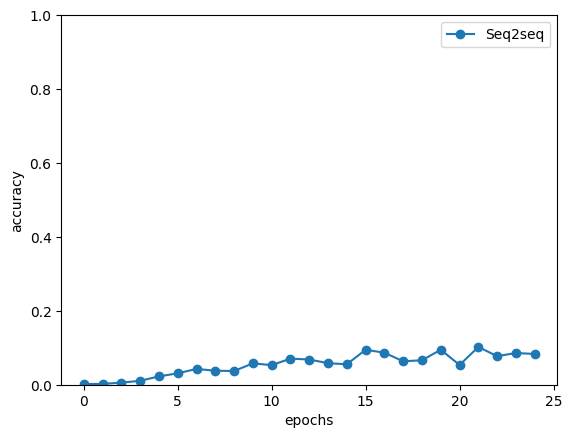

In [18]:
# coding: utf-8
# train_seq2seq.py


# データセットの読み込み
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()

# Reverse input? =================================================
is_reverse = False  # True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# ハイパーパラメータの設定
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# Normal or Peeky? ==============================================
model = Seq2seq(vocab_size, wordvec_size, hidden_size)
# model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
# ================================================================
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('val acc %.3f%%' % (acc * 100))

# 結果を保存
np.save('acc_1_seq2seq.npy', np.array(acc_list))

# グラフの描画
x = np.arange(len(acc_list))
plt.plot(x, acc_list, marker='o', label='Seq2seq')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.ylim(0, 1.0)
plt.legend()
plt.show()


### 7.4.2 入力を反転した seq2seq
次に `is_reverse = True` として、入力系列を時間方向に反転します。モデル構造は通常の `Seq2seq` のままなので、反転という前処理だけで性能がどのように変わるかを確認できます。


| epoch 1 |  iter 1 / 351 | time 0[s] | loss 2.56
| epoch 1 |  iter 21 / 351 | time 0[s] | loss 2.52
| epoch 1 |  iter 41 / 351 | time 0[s] | loss 2.17
| epoch 1 |  iter 61 / 351 | time 1[s] | loss 1.96
| epoch 1 |  iter 81 / 351 | time 1[s] | loss 1.91
| epoch 1 |  iter 101 / 351 | time 2[s] | loss 1.87
| epoch 1 |  iter 121 / 351 | time 2[s] | loss 1.86
| epoch 1 |  iter 141 / 351 | time 3[s] | loss 1.84
| epoch 1 |  iter 161 / 351 | time 3[s] | loss 1.80
| epoch 1 |  iter 181 / 351 | time 3[s] | loss 1.78
| epoch 1 |  iter 201 / 351 | time 4[s] | loss 1.77
| epoch 1 |  iter 221 / 351 | time 4[s] | loss 1.77
| epoch 1 |  iter 241 / 351 | time 5[s] | loss 1.76
| epoch 1 |  iter 261 / 351 | time 5[s] | loss 1.75
| epoch 1 |  iter 281 / 351 | time 5[s] | loss 1.74
| epoch 1 |  iter 301 / 351 | time 6[s] | loss 1.74
| epoch 1 |  iter 321 / 351 | time 7[s] | loss 1.74
| epoch 1 |  iter 341 / 351 | time 7[s] | loss 1.73
Q 77+85  
T 162 
☒ 100 
---
Q 975+164
T 1139
☒ 1000
---
Q 582+84 
T 66

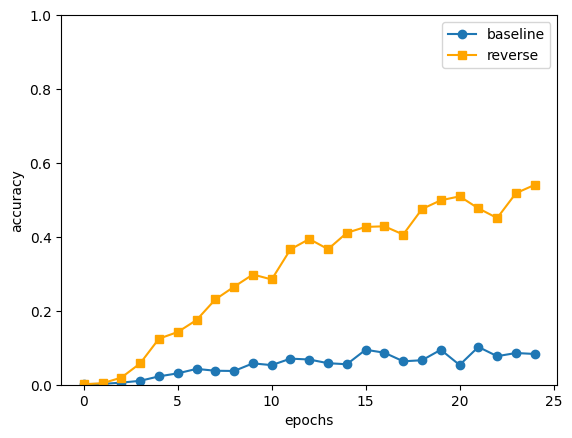

In [19]:
# coding: utf-8
# train_seq2seq.py


# データセットの読み込み
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()

# Reverse input? =================================================
is_reverse = True  # True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# ハイパーパラメータの設定
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# Normal or Peeky? ==============================================
model = Seq2seq(vocab_size, wordvec_size, hidden_size)
# model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
# ================================================================
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('val acc %.3f%%' % (acc * 100))

# 結果を保存
np.save('acc_2_seq2seq_reverse.npy', np.array(acc_list))

# 1回目の結果を読み込み
acc_1 = np.load('acc_1_seq2seq.npy')

# グラフの描画
x1 = np.arange(len(acc_1))
x2 = np.arange(len(acc_list))

plt.plot(x1, acc_1, marker='o', label='baseline')
plt.plot(x2, acc_list, color='orange', marker='s', label='reverse')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.ylim(0, 1.0)
plt.legend()
plt.show()


### 7.4.3 Peeky seq2seq
最後に、入力を反転したうえで `PeekySeq2seq` を使います。Peeky Decoder は各時刻で Encoder の隠れ状態を参照できるため、通常の Decoder よりも入力情報を活用しやすくなります。足し算タスクでは、入力反転と Peeky Decoder を組み合わせることで精度向上が期待できます。


| epoch 1 |  iter 1 / 351 | time 0[s] | loss 2.57
| epoch 1 |  iter 21 / 351 | time 0[s] | loss 2.48
| epoch 1 |  iter 41 / 351 | time 0[s] | loss 2.20
| epoch 1 |  iter 61 / 351 | time 1[s] | loss 1.99
| epoch 1 |  iter 81 / 351 | time 2[s] | loss 1.89
| epoch 1 |  iter 101 / 351 | time 2[s] | loss 1.82
| epoch 1 |  iter 121 / 351 | time 3[s] | loss 1.82
| epoch 1 |  iter 141 / 351 | time 3[s] | loss 1.80
| epoch 1 |  iter 161 / 351 | time 4[s] | loss 1.79
| epoch 1 |  iter 181 / 351 | time 4[s] | loss 1.78
| epoch 1 |  iter 201 / 351 | time 5[s] | loss 1.77
| epoch 1 |  iter 221 / 351 | time 5[s] | loss 1.76
| epoch 1 |  iter 241 / 351 | time 5[s] | loss 1.76
| epoch 1 |  iter 261 / 351 | time 6[s] | loss 1.75
| epoch 1 |  iter 281 / 351 | time 6[s] | loss 1.74
| epoch 1 |  iter 301 / 351 | time 7[s] | loss 1.74
| epoch 1 |  iter 321 / 351 | time 7[s] | loss 1.73
| epoch 1 |  iter 341 / 351 | time 8[s] | loss 1.73
Q 77+85  
T 162 
☒ 100 
---
Q 975+164
T 1139
☒ 1013
---
Q 582+84 
T 66

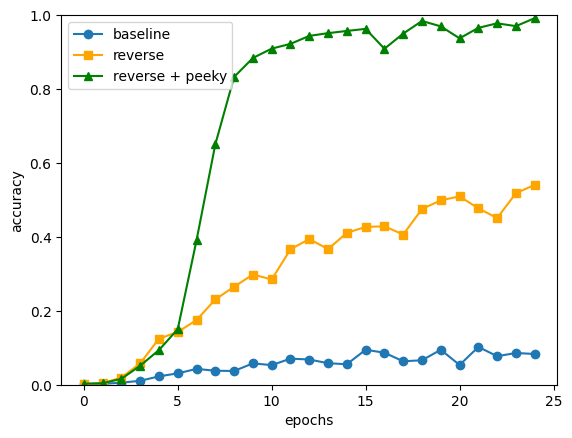

In [20]:
# coding: utf-8
# train_seq2seq.py


# データセットの読み込み
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()

# Reverse input? =================================================
is_reverse = True  # True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# ハイパーパラメータの設定
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# Normal or Peeky? ==============================================
# model = Seq2seq(vocab_size, wordvec_size, hidden_size)
model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
# ================================================================
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('val acc %.3f%%' % (acc * 100))

# 結果を保存
np.save('acc_3_peeky_seq2seq_reverse.npy', np.array(acc_list))

# 1回目・2回目の結果を読み込み
acc_1 = np.load('acc_1_seq2seq.npy')
acc_2 = np.load('acc_2_seq2seq_reverse.npy')

# グラフの描画
x1 = np.arange(len(acc_1))
x2 = np.arange(len(acc_2))
x3 = np.arange(len(acc_list))

plt.plot(x1, acc_1, marker='o', label='baseline')
plt.plot(x2, acc_2, color='orange', marker='s', label='reverse')
plt.plot(x3, acc_list, color='green', marker='^', label='reverse + peeky')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.ylim(0, 1.0)
plt.legend()
plt.show()

## 7.5 まとめ

* 言語モデルは、次の単語を確率分布として出力できるため、サンプリングを繰り返すことで文章生成に利用できます。  
* seq2seq は Encoder が入力系列を読み込み、Decoder が出力系列を生成するモデルです。  
* 足し算データセットのような文字列変換問題にも seq2seq を適用できます。  
* 入力系列の反転は、重要な情報を Decoder に近づけるシンプルな改善です。  
* Peeky Decoder は Encoder の隠れ状態を Decoder の各時刻へ直接渡し、入力情報をより活用しやすくします。
